In [46]:
from matplotlib.colors import ListedColormap
import torch
import nrrd 
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models 
from torch.utils.data import Dataset,DataLoader,Subset
from model.LeNet5 import LeNet
import numpy as np
import os
from PIL import Image, ImageOps
from torchvision import transforms
from pathlib import Path
from typing import Dict, Optional
import re
from torch.utils.data import random_split
from collections import Counter
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.optim as optim
import wandb
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score

In [47]:
#Global variable
pattern=re.compile(r"^Segment(\d+)_Tags$")
Segment_signal_string="Segmentation.Status:inprogress"
label_type={'binh_thuong':0,
            'dut_ban_phan_1_3_giua':1,
            'dut_hoan_toan_1_3_giua':2,
            'dut_ban_phan_1_3_duoi':3,
            'dut_hoan_toan_1_3_duoi':4, # Khong co class dut hoan toan 1/3 duoi nen class dut hoan toan 1/3 tren se la class 4
            'dut_hoan_toan_1_3_tren':4,
            'dut_ban_phan_1_3_tren':5
            }
sweep_config={
    'method':'random',
    'metric':{
        'name':'Validation Accuracy',
        'goal':'maximize'
    },
    'parameters':{
        'lr':{
            'values':[0.01,0.001,0.0001]
        },
        'epoch':{
            'values':[20,30,40]
        },
        'batch_size':{
            'values':[2,4,8,16]
        },
        'optim':{
            'values':['SGD']
        }
    }
}


<>:105: SyntaxWarning: invalid escape sequence '\p'
<>:105: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_24396\1862520959.py:105: SyntaxWarning: invalid escape sequence '\p'
  root_dir='D:\personal_data\Duy Phan Ig\my_tool\data',


Scanning folder: 2025_12_22_Thuan
Number of selected files: 20
Scanning folder: 2025_14_11_Thanh
Number of selected files: 19
Scanning folder: 2026_1_18_Thuan
Number of selected files: 17
Scanning folder: 2026_1_2_Thanh
Number of selected files: 20
Scanning folder: 26_01_02_Thanh
Number of selected files: 22
Scanning folder: 26_16_02_Thuan
Number of selected files: 52
Scanning folder: 26_27_02_Thanh
Number of selected files: 20

ACL type distribution:
Total patient: 170
dut_hoan_toan_1_3_giua: 29
dut_hoan_toan_1_3_tren: 33
dut_ban_phan_1_3_giua: 30
dut_ban_phan_1_3_tren: 21
dut_ban_phan_1_3_duoi: 17
binh_thuong: 37
segment_1: 3


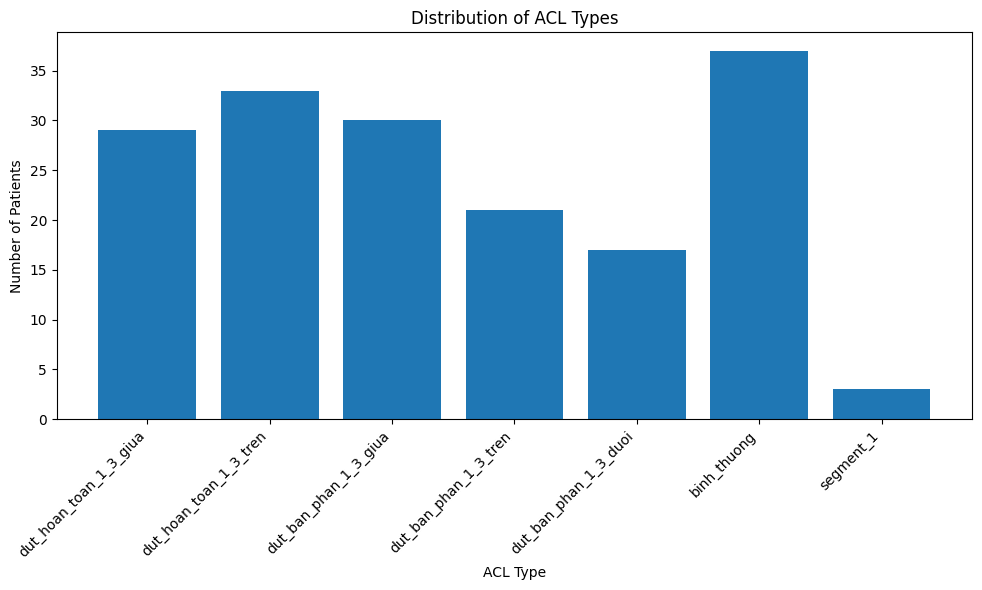

In [48]:

class ACLDataCollector:
    def __init__(
        self,
        root_dir: str,
        pattern: str,
        segment_signal_string: str,
        image_keyword: str = "t2_tse_sag",
        seg_keyword: str = "Segmentation*.seg.nrrd",
    ):
        self.root_dir = Path(root_dir)
        self.pattern = re.compile(pattern)
        self.segment_signal_string = segment_signal_string
        self.image_keyword = image_keyword.lower()
        self.seg_keyword = seg_keyword
        self.all_patients: Dict[str, Dict] = {}
        self.type_count: Dict[str, int] = {}

    def get_acl_indices(self, seg_header: dict):
        seg_indices = []
        for k in seg_header.keys():
            m = self.pattern.match(k)
            if m:
                seg_indices.append(m.group(1))
        return seg_indices

    def get_acl_type(self, seg_header: Dict) -> Optional[str]:
        indices = self.get_acl_indices(seg_header)
        for idx in indices:
            tag_key = f"Segment{idx}_Tags"
            name_key = f"Segment{idx}_Name"

            if tag_key in seg_header and name_key in seg_header:
                value = str(seg_header[tag_key])
                if value.startswith(self.segment_signal_string):
                    return str(seg_header[name_key]).lower()
        return None

    def collect_data_and_seg(self, folder_path: Path) -> Dict:
        result = {}
        for subfolder in folder_path.iterdir():
            if not subfolder.is_dir():
                continue
            seg_files = sorted(subfolder.glob(self.seg_keyword))
            t2_files = sorted(
                p for p in subfolder.glob("*.nrrd")
                if self.image_keyword in p.stem.lower()
            )
            if not seg_files or not t2_files:
                continue
            _, seg_header = nrrd.read(str(seg_files[0]))
            acl_type = self.get_acl_type(seg_header)

            result[subfolder.name] = {
                "nrrd": str(t2_files[0]),
                "seg": str(seg_files[0]),
                "type": acl_type,
            }
        return result
    def collect_all(self) -> Dict:
        self.all_patients = {}
        for sub_folder in self.root_dir.iterdir():
            if not sub_folder.is_dir():
                continue
            print(f"Scanning folder: {sub_folder.name}")
            data_dict = self.collect_data_and_seg(sub_folder)
            self.all_patients.update(data_dict)
            print(f"Number of selected files: {len(data_dict)}")

        return self.all_patients

    def count_acl_types(self) -> Dict[str, int]:
        self.type_count = {}
        for _, data in self.all_patients.items():
            acl_type = data["type"] if data["type"] is not None else "unknown"
            self.type_count[acl_type] = self.type_count.get(acl_type, 0) + 1
        return self.type_count

    def print_summary(self):
        if not self.type_count:
            self.count_acl_types()
        print("\nACL type distribution:")
        print(f"Total patient: {len(self.all_patients)}")
        for k, v in self.type_count.items():
            print(f"{k}: {v}")

    def plot_distribution(self):
        if not self.type_count:
            self.count_acl_types()

        labels = list(self.type_count.keys())
        counts = list(self.type_count.values())

        plt.figure(figsize=(10, 6))
        plt.bar(labels, counts)
        plt.xlabel("ACL Type")
        plt.ylabel("Number of Patients")
        plt.title("Distribution of ACL Types")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":

    collector = ACLDataCollector(
        root_dir='D:\personal_data\Duy Phan Ig\my_tool\data',
        # root_dir=r"D:\Project\ACL\my_tool\data",
        pattern=pattern,
        segment_signal_string=Segment_signal_string
    )

    all_patients=collector.collect_all()
    collector.count_acl_types()
    collector.print_summary()
    collector.plot_distribution()

In [49]:
class MRI_data(Dataset):
    def __init__(
        self,
        data_dict: Dict,
        img_trasform=None,
        label_transform=None,
        target_size=(320,320),
        target_depth=25
    ):
        self.data_dict = data_dict
        self.img_transform = img_trasform
        self.label_transform = label_transform
        self.target_size = target_size
        self.target_depth = target_depth
        self.samples = []
        num_patient = 0
        for patient, data in data_dict.items():
            nrrd_path = data['nrrd']
            seg_path = data['seg']
            nrrd_data, _ = nrrd.read(nrrd_path)
            seg_data, _ = nrrd.read(seg_path)
            type_acl = data['type']
            if type_acl == 'segment_1':
                print("Skipping segment_1 label")
                continue
            if nrrd_data.shape != seg_data.shape:
                print(f"Mismatch shape for {patient}: image={nrrd_data.shape}, seg={seg_data.shape}")
                continue
            self.samples.append((nrrd_data, label_type[type_acl]))
            num_patient += 1
        print(f"Number of patient selected / total: {num_patient}/{len(data_dict)}")

    def __len__(self):
        return len(self.samples)

    def fix_depth(self, volume):
        """
        volume shape = (H,W,D)
        """
        H, W, D = volume.shape

        if D > self.target_depth:
            start = (D - self.target_depth) // 2
            volume = volume[:, :, start:start + self.target_depth]

        elif D < self.target_depth:
            pad = self.target_depth - D
            pad_before = pad // 2
            pad_after = pad - pad_before

            volume = np.pad(
                volume,
                ((0,0),(0,0),(pad_before,pad_after)),
                mode="constant"
            )
        return volume

    def __getitem__(self, index):

        img, label = self.samples[index]

        # normalize
        img = img / (np.max(img) + 1e-8)

        # fix slice depth
        img = self.fix_depth(img)

        # convert to tensor
        img = torch.tensor(img, dtype=torch.float32).permute(2,0,1)  # (D,H,W)
        img = img.unsqueeze(0)  # (1,D,H,W)

        label = torch.tensor(label, dtype=torch.long)

        if self.img_transform:
            img = self.img_transform(img)

        if self.label_transform:
            label = self.label_transform(label)

        return img, label

In [50]:
img_transform=transforms.Compose([
    transforms.CenterCrop((160,160)),
])
dataset=MRI_data(data_dict=all_patients,img_trasform=img_transform)

Mismatch shape for BUI NGUYEN BAO QUOC (18024987): image=(608, 608, 25), seg=(544, 544, 29)
Mismatch shape for MAI THI BICH LOC (25073019): image=(608, 608, 25), seg=(512, 512, 29)
Mismatch shape for TRUONG THI BAO NGOC 25111764: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Cai Kim Loc_25210566: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Le Thi Thuy_25193052: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Le Van Chung_25938957: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Nguyen Hoang Gia Tuan_20250616: image=(608, 608, 25), seg=(512, 512, 29)
Mismatch shape for Nguyen Huu Nghia_25246508: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Nguyen Minh Luan_24281378: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Nguyen Ngoc Dang Duong_20250529 (loi ve): image=(608, 608, 25), seg=(512, 512, 29)
Mismatch shape for Nguyen Ngoc Long_20250911: image=(352, 352, 23), seg=(320, 320, 27)
Mismatch shape for Nguyen T

In [51]:
print(f"Dataset length: {len(dataset)}")
print(f"Sample image shape: {dataset[39][0].shape}, Sample label: {dataset[39][1]}")


Dataset length: 120
Sample image shape: torch.Size([1, 25, 160, 160]), Sample label: 1


In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class MRI_3D_CNN(nn.Module):
    def __init__(self, num_classes: int = 3, in_channels: int = 1):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv3d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),   # [D,H,W] -> [D/2,H/2,W/2]

            # Block 2
            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),

            # Make output size fixed regardless of input spatial size
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),              # [B,128,1,1,1] -> [B,128]
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        """
        x shape: [B, C, D, H, W]
        """
        x = self.features(x)
        x = self.classifier(x)
        return x

In [61]:
model = MRI_3D_CNN(num_classes=6, in_channels=1)
print(model)

MRI_3D_CNN(
  (features): Sequential(
    (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (13): BatchNorm3

In [54]:
labels = [label for _, label in dataset.samples]
indices = list(range(len(dataset)))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
print(f"Len of train set: {len(train_dataset)}")
print(f"Len of val set: {len(val_dataset)}")

Len of train set: 84
Len of val set: 36


Overall Dataset Label Distribution:


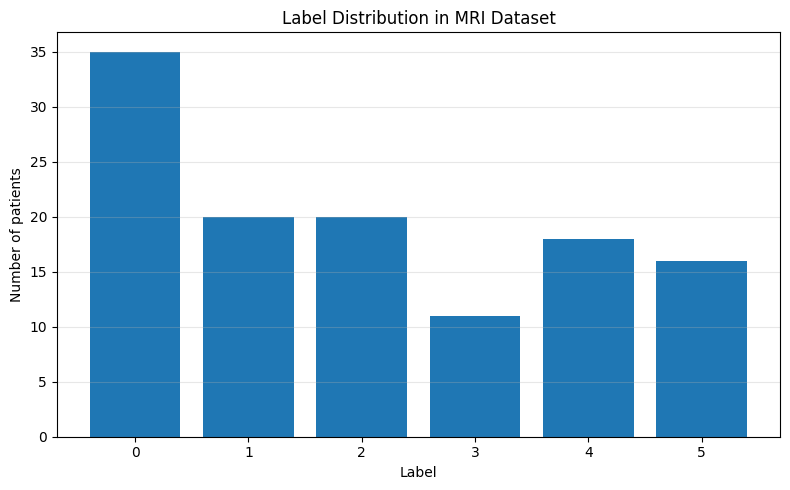

Label 0: 35 samples
Label 1: 20 samples
Label 2: 20 samples
Label 3: 11 samples
Label 4: 18 samples
Label 5: 16 samples
Training Set Label Distribution:


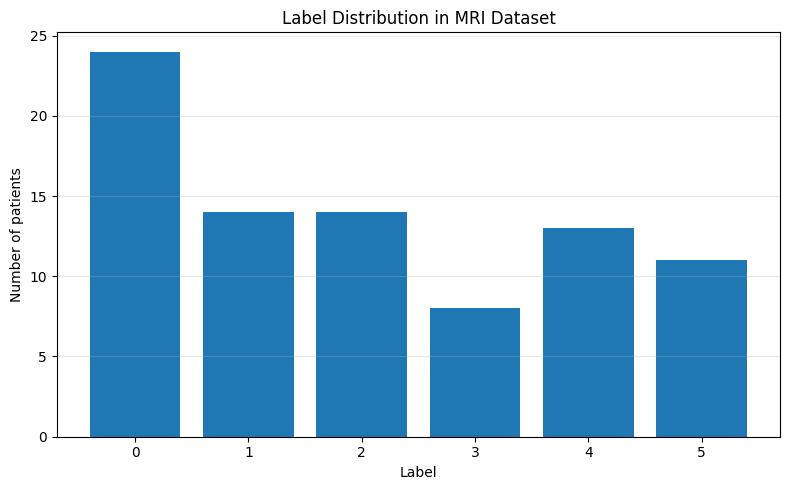

Label 0: 24 samples
Label 1: 14 samples
Label 2: 14 samples
Label 3: 8 samples
Label 4: 13 samples
Label 5: 11 samples
Validation Set Label Distribution:


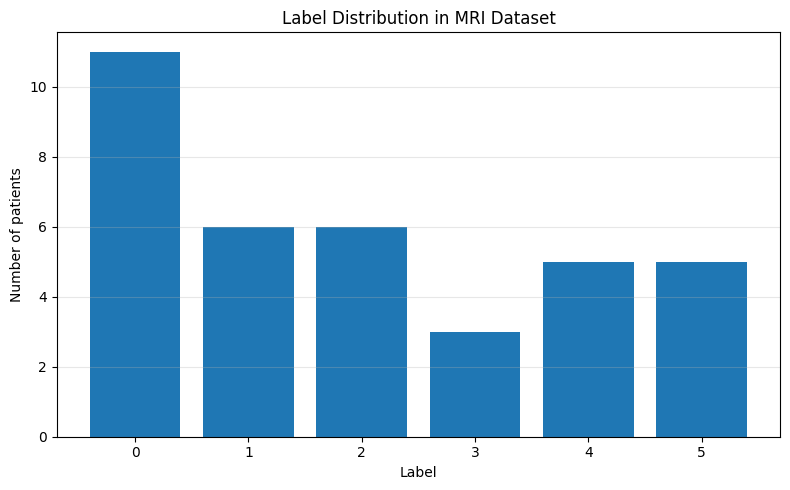

Label 0: 11 samples
Label 1: 6 samples
Label 2: 6 samples
Label 3: 3 samples
Label 4: 5 samples
Label 5: 5 samples


In [55]:
def plot_label_distribution(dataset):
    labels = []
    for _, label in dataset:
        # handle torch tensor labels
        if isinstance(label, torch.Tensor):
            label = label.item()
        labels.append(label)
    label_counts = Counter(labels)
    # sort by label index
    labels_sorted = sorted(label_counts.keys())
    counts_sorted = [label_counts[l] for l in labels_sorted]
    plt.figure(figsize=(8, 5))
    plt.bar(labels_sorted, counts_sorted)
    plt.xlabel("Label")
    plt.ylabel("Number of patients")
    plt.title("Label Distribution in MRI Dataset")
    plt.xticks(labels_sorted)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    # also print counts
    for l in labels_sorted:
        print(f"Label {l}: {label_counts[l]} samples")
# Plot label distribution for the entire dataset, training set, and validation set
print("Overall Dataset Label Distribution:")
plot_label_distribution(dataset)
print("Training Set Label Distribution:")
plot_label_distribution(train_dataset)
print("Validation Set Label Distribution:")
plot_label_distribution(val_dataset)

In [56]:
wandb.login()

True

In [57]:
def compute_class_weights(full_dataset, train_subset, num_classes):
    train_labels = [full_dataset.samples[i][1] for i in train_subset.indices]
    counts = Counter(train_labels)

    print("Training label counts:", counts)

    total = sum(counts.values())

    weights = []
    for c in range(num_classes):
        if counts[c] == 0:
            weights.append(0.0)
        else:
            weights.append(total / counts[c])

    weights = torch.tensor(weights, dtype=torch.float32)
    return weights

In [58]:
class TrainerWB:
    def __init__(self, config, train_loader, val_loader, model, class_weights=None):
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.epochs = config.epoch
        self.lr = config.lr

        self.train_loader = train_loader
        self.val_loader = val_loader
        self.model = model.to(self.device)

        if class_weights is not None:
            self.criterion = nn.CrossEntropyLoss(weight=class_weights.to(self.device))
        else:
            self.criterion = nn.CrossEntropyLoss()

        self.optimizer = self.build_optimizer()

    def build_optimizer(self):
        if self.config.optim == "SGD":
            return optim.SGD(
                self.model.parameters(),
                lr=self.lr,
                momentum=0.9
            )
        elif self.config.optim == "Adam":
            return optim.Adam(
                self.model.parameters(),
                lr=self.lr
            )
        else:
            raise ValueError(f"Unsupported optimizer: {self.config.optim}")

    def train_one_epoch(self):
        self.model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(self.train_loader, desc="Training", leave=False)

        for images, labels in loop:
            images = images.to(self.device)
            labels = labels.to(self.device)

            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += batch_size

            loop.set_postfix(
                loss=running_loss / total,
                acc=correct / total
            )

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        return epoch_loss, epoch_acc

    def validate_one_epoch(self):
        self.model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in self.val_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                batch_size = images.size(0)
                running_loss += loss.item() * batch_size

                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += batch_size

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = running_loss / total
        val_acc = correct / total

        macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
        balanced_acc = balanced_accuracy_score(all_labels, all_preds)
        cm = confusion_matrix(all_labels, all_preds)

        return val_loss, val_acc, macro_f1, weighted_f1, balanced_acc, cm

    def fit(self, print_every=1, cm_every=5):
        for epoch in range(1, self.epochs + 1):
            train_loss, train_acc = self.train_one_epoch()
            val_loss, val_acc, macro_f1, weighted_f1, balanced_acc, cm = self.validate_one_epoch()

            if epoch % print_every == 0:
                print(f"\nEpoch [{epoch}/{self.epochs}]")
                print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
                print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")
                print(f"Macro F1:   {macro_f1:.4f}")
                print(f"Weighted F1:{weighted_f1:.4f}")
                print(f"Balanced Acc: {balanced_acc:.4f}")

            if epoch % cm_every == 0:
                print("\nConfusion Matrix:")
                print(cm)

            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss,
                "train_accuracy": train_acc,
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "val_macro_f1": macro_f1,
                "val_weighted_f1": weighted_f1,
                "val_balanced_accuracy": balanced_acc
            })

        print("Training complete.")

In [59]:
def main():
    with wandb.init(project="ACL_Classification_3D_CNN", reinit=True):
        num_classes=6
        config=wandb.config
        train_loader = DataLoader(train_dataset,batch_size=config.batch_size,shuffle=True)
        val_loader = DataLoader(val_dataset,batch_size=config.batch_size,shuffle=False)
        class_weights = compute_class_weights(
            full_dataset=dataset,
            train_subset=train_dataset,
            num_classes=num_classes
        )
        trainer = TrainerWB(
            config=config,
            train_loader=train_loader,
            val_loader=val_loader,
            model=model,
            class_weights=class_weights
        )
        trainer.fit(print_every=1,cm_every=5)

In [ ]:
sweep_id= wandb.sweep(sweep_config, project="ACL_Classification_3D_CNN")
wandb.agent(sweep_id, function=main, count=10)

Create sweep with ID: zkg75erm
Sweep URL: https://wandb.ai/baymaxnguyen306-ho-chi-minh-city-university-of-technology/ACL_Classification_3D_CNN/sweeps/zkg75erm


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: w6fk11uh with config:
wandb: 	batch_size: 2
wandb: 	epoch: 30
wandb: 	lr: 0.01
wandb: 	optim: SGD


Training label counts: Counter({0: 24, 1: 14, 2: 14, 4: 13, 5: 11, 3: 8})



Epoch [1/30]
Train Loss: 1.8825, Train Acc: 0.1548
Val Loss:   1.8230, Val Acc:   0.3611
Macro F1:   0.1569
Weighted F1:0.2281
Balanced Acc: 0.2348



Epoch [2/30]
Train Loss: 1.8312, Train Acc: 0.1190
Val Loss:   1.7892, Val Acc:   0.1667
Macro F1:   0.0743
Weighted F1:0.1140
Balanced Acc: 0.1162


...


Epoch [8/20]
Train Loss: 1.7396, Train Acc: 0.3214
Val Loss:   1.8213, Val Acc:   0.3056
Macro F1:   0.1435
Weighted F1:0.2036
Balanced Acc: 0.2045



Epoch [9/20]
Train Loss: 1.7377, Train Acc: 0.2857
Val Loss:   1.8201, Val Acc:   0.3056
Macro F1:   0.1435
Weighted F1:0.2036
Balanced Acc: 0.2045



Epoch [10/20]
Train Loss: 1.7364, Train Acc: 0.3452
Val Loss:   1.8194, Val Acc:   0.3056
Macro F1:   0.1435
Weighted F1:0.2036
Balanced Acc: 0.2045

Confusion Matrix:
[[8 0 3 0 0 0]
 [6 0 0 0 0 0]
 [2 0 3 0 0 1]
 [2 0 0 0 0 1]
 [4 0 1 0 0 0]
 [4 0 1 0 0 0]]



Epoch [11/20]
Train Loss: 1.7187, Train Acc: 0.3095
Val Loss:   1.8193, Val Acc:   0.3056
Macro F1:   0.1435
Weighted F1:0.2036
Balanced Acc: 0.2045



Epoch [12/20]
Train Loss: 1.7254, Train Acc: 0.3214
Val Loss:   1.8187, Val Acc:   0.2778
Macro F1:   0.1234
Weighted F1:0.1834
Balanced Acc: 0.1768
